In [5]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

# Downloaded IDEA data

Downloaded from https://idea.research.calicolabs.com/data

In [7]:
idea_kinetics = pd.read_csv("../../../data/idea_kinetics.tsv", sep = "\t")
idea_kinetics

,tc_id,model,rate,t_fall,t_rise,v_final,v_inter,GeneName,exp_id,TF
0,1,sigmoid,0.258761,NaN,44.763805,NaN,0.653032,AAD10,1,ACA1
1,2,sigmoid,0.126136,NaN,45.535603,NaN,-2.109710,AAP1,1,ACA1
2,3,sigmoid,0.083823,NaN,22.377916,NaN,-0.615029,AAT1,1,ACA1
3,4,sigmoid,0.064759,NaN,29.290289,NaN,-0.620696,ABF1,1,ACA1
4,5,sigmoid,1.174821,NaN,3.653315,NaN,5.377406,ACA1,1,ACA1
...,...,...,...,...,...,...,...,...,...,...
100031,100032,sigmoid,1.014049,NaN,2.947076,NaN,-1.460898,YGL152C,217,ZNF1
100032,100033,sigmoid,0.715342,NaN,9.862979,NaN,-0.414272,YHK8,217,ZNF1
100033,100034,sigmoid,1.217390,NaN,6.739437,NaN,0.960504,YJL086C,217,ZNF1
100034,100035,sigmoid,1.115343,NaN,17.460293,NaN,-1.514096,YOR146W,217,ZNF1


In [8]:
def get_half_max_time(row):
    if row['model'] == 'sigmoid':
        return row['t_rise']
    elif row['model'] == 'impulse':
        # two half-max times; return both or just the rising one depending on your use case
        return row['t_rise']  # or t_fall, or min/mean of both

idea_kinetics['half_max_time'] = idea_kinetics.apply(get_half_max_time, axis=1)
idea_kinetics["half_max_time"] = 1 / idea_kinetics["half_max_time"]
idea_kinetics

,tc_id,model,rate,t_fall,t_rise,v_final,v_inter,GeneName,exp_id,TF,half_max_time
0,1,sigmoid,0.258761,NaN,44.763805,NaN,0.653032,AAD10,1,ACA1,0.022339
1,2,sigmoid,0.126136,NaN,45.535603,NaN,-2.109710,AAP1,1,ACA1,0.021961
2,3,sigmoid,0.083823,NaN,22.377916,NaN,-0.615029,AAT1,1,ACA1,0.044687
3,4,sigmoid,0.064759,NaN,29.290289,NaN,-0.620696,ABF1,1,ACA1,0.034141
4,5,sigmoid,1.174821,NaN,3.653315,NaN,5.377406,ACA1,1,ACA1,0.273724
...,...,...,...,...,...,...,...,...,...,...,...
100031,100032,sigmoid,1.014049,NaN,2.947076,NaN,-1.460898,YGL152C,217,ZNF1,0.339319
100032,100033,sigmoid,0.715342,NaN,9.862979,NaN,-0.414272,YHK8,217,ZNF1,0.101389
100033,100034,sigmoid,1.217390,NaN,6.739437,NaN,0.960504,YJL086C,217,ZNF1,0.148380
100034,100035,sigmoid,1.115343,NaN,17.460293,NaN,-1.514096,YOR146W,217,ZNF1,0.057273


In [9]:
len(idea_kinetics["GeneName"].unique())

6166

# Aggregating TF target speeds

In [10]:
def aggregate_kinetics(df, col, prefix, cv_threshold=0.5):
    result = (
        df.groupby("TF")[col]
        .agg(
            **{f"{prefix}_mean":         'mean'},
            **{f"{prefix}_std":          'std'},
            **{f"{prefix}_median":       'median'},
            **{f"{prefix}_max":          'max'},
            **{f"{prefix}_top5_mean":    lambda x: x.nlargest(5).mean()},
            **{f"{prefix}_top25_mean":   lambda x: x.nlargest(25).mean()},
            **{f"{prefix}_top50_mean":   lambda x: x.nlargest(50).mean()},
            **{f"n_targets":             'count'},
        )
        .reset_index()
        .rename(columns={"TF": "gene"})
    )

    # CV computed ONLY from full distribution
    result["cv"] = result[f"{prefix}_std"] / result[f"{prefix}_mean"].abs()

    # 🔒 Only mask GLOBAL stats (NOT top-k)
    global_cols = [
        f"{prefix}_mean",
        f"{prefix}_std",
        f"{prefix}_median",
        f"{prefix}_max",
    ]

    result.loc[result["cv"] > cv_threshold, global_cols] = pd.NA

    return result

tf_kinetics_halfmax = aggregate_kinetics(idea_kinetics, "half_max_time", "half_max")
tf_kinetics_rate    = aggregate_kinetics(idea_kinetics, "rate",          "rate")

tf_kinetics = tf_kinetics_halfmax.merge(
    tf_kinetics_rate.drop(columns=["n_targets"]),  # cv no longer a column; only drop n_targets
    on="gene"
)
tf_kinetics

,gene,half_max_mean,half_max_std,half_max_median,half_max_max,half_max_top5_mean,half_max_top25_mean,half_max_top50_mean,n_targets,cv_x,rate_mean,rate_std,rate_median,rate_max,rate_top5_mean,rate_top25_mean,rate_top50_mean,cv_y
0,ACA1,NaN,NaN,NaN,NaN,0.238617,0.159838,0.127282,772,0.896240,NaN,NaN,NaN,NaN,1.209318,0.894362,0.728189,0.689330
1,ACE2,NaN,NaN,NaN,NaN,0.320412,0.156886,0.114955,529,0.770666,NaN,NaN,NaN,NaN,1.149052,0.755313,0.616603,0.581265
2,ADA2,NaN,NaN,NaN,NaN,0.212930,0.097094,0.073316,67,0.854958,NaN,NaN,NaN,NaN,1.034118,0.605176,0.451580,0.640777
3,ADR1,NaN,NaN,NaN,NaN,0.432886,0.251012,0.141828,135,1.590722,NaN,NaN,NaN,NaN,0.944952,0.631602,0.465573,0.731725
4,AFT1,0.044637,0.022055,0.043582,0.415194,0.225566,0.124688,0.104603,1183,0.494098,0.328086,0.118077,0.330993,1.193047,0.945100,0.667516,0.598308,0.359896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,YRM1,NaN,NaN,NaN,NaN,0.166903,0.062860,0.042281,62,1.155719,NaN,NaN,NaN,NaN,1.093017,0.550790,0.393810,0.901083
199,YRR1,NaN,NaN,NaN,NaN,0.191578,0.109596,0.084099,119,0.751952,NaN,NaN,NaN,NaN,1.873898,0.989122,0.806035,0.806505
200,Z3EV,NaN,NaN,NaN,NaN,0.390771,0.246648,0.176464,38,0.774929,NaN,NaN,NaN,NaN,1.242936,0.877646,0.670895,0.542071
201,ZAP1,NaN,NaN,NaN,NaN,0.238194,0.216494,0.196670,889,0.798812,NaN,NaN,NaN,NaN,1.955525,1.147077,0.971306,0.571646


# Loading in trebl speeds

In [11]:
trebl_speeds = pd.read_csv("../../../output/ChopTFs_pipeline/speed/aggreg_per_TF.csv", index_col = 0)
trebl_speeds

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136
...,...,...,...,...,...,...,...,...
143,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955
144,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455
145,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682


# Comparing speeds

In [73]:
import pandas as pd
from scipy import stats

merged = tf_kinetics.merge(trebl_speeds, on='gene')

kinetics_cols = [
    'half_max_mean', 'half_max_median', 'half_max_trimmed_mean',
    'rate_mean', 'rate_median', 'rate_max',
    'rate_top5_mean', 'rate_trimmed_mean', "rate_top50_mean",'rate_top25_mean', 
]
speed_cols = [
    'max_speed', 'mean_speed', 
    'median_speed', 'top3_mean_speed'
]

rows = []
for k in kinetics_cols:
    for s in speed_cols:
        if k not in merged.columns:
            continue
        tmp = merged[[k, s]].dropna()
        r, p = stats.spearmanr(tmp[k], tmp[s])
        rows.append({'kinetics': k, 'trebl_speed': s, 'r': r, 'p': p, 'n': len(tmp)})

corr_df = pd.DataFrame(rows).sort_values('p', key=abs, ascending=True)
display(corr_df)

,kinetics,trebl_speed,r,p,n
8,rate_mean,max_speed,0.614035,0.006711,18
12,rate_median,max_speed,0.595459,0.009126,18
11,rate_mean,top3_mean_speed,0.593395,0.009433,18
15,rate_median,top3_mean_speed,0.589267,0.010071,18
28,rate_top25_mean,max_speed,0.227054,0.068929,65
24,rate_top50_mean,max_speed,0.219012,0.079633,65
9,rate_mean,mean_speed,0.415893,0.086056,18
13,rate_median,mean_speed,0.405573,0.094953,18
10,rate_mean,median_speed,0.380805,0.118984,18
20,rate_top5_mean,max_speed,0.191390,0.126699,65


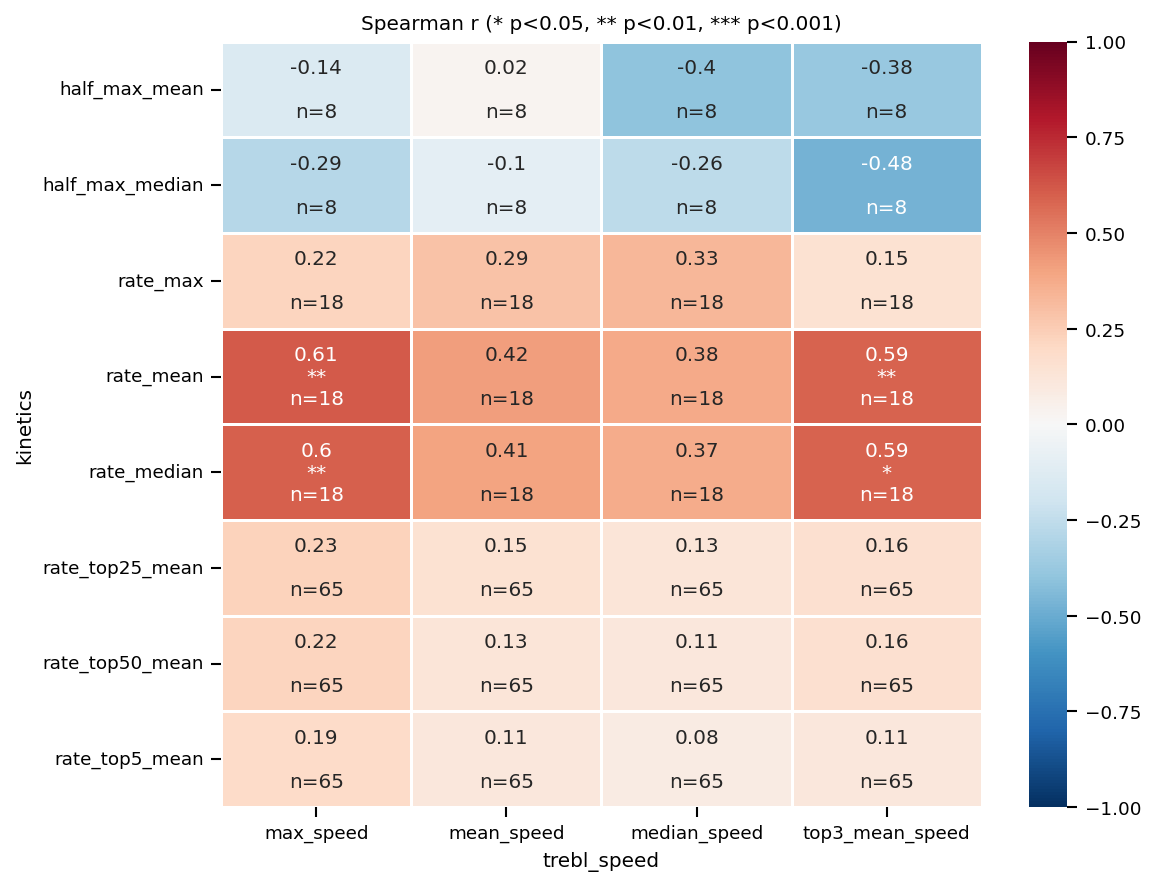

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('paper')
pivot_r = corr_df.pivot(index='kinetics', columns='trebl_speed', values='r')
pivot_p = corr_df.pivot(index='kinetics', columns='trebl_speed', values='p')
pivot_n = corr_df.pivot(index='kinetics', columns='trebl_speed', values='n')

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

annot = (
    pivot_r.round(2).astype(str)
    + '\n' +
    pivot_p.applymap(sig_stars)
    + '\n' +
    pivot_n.fillna(0).astype(int).astype(str).radd('n=')
)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sns.heatmap(
    pivot_r, annot=annot, fmt='', center=0,
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Spearman r (* p<0.05, ** p<0.01, *** p<0.001)')
plt.tight_layout()

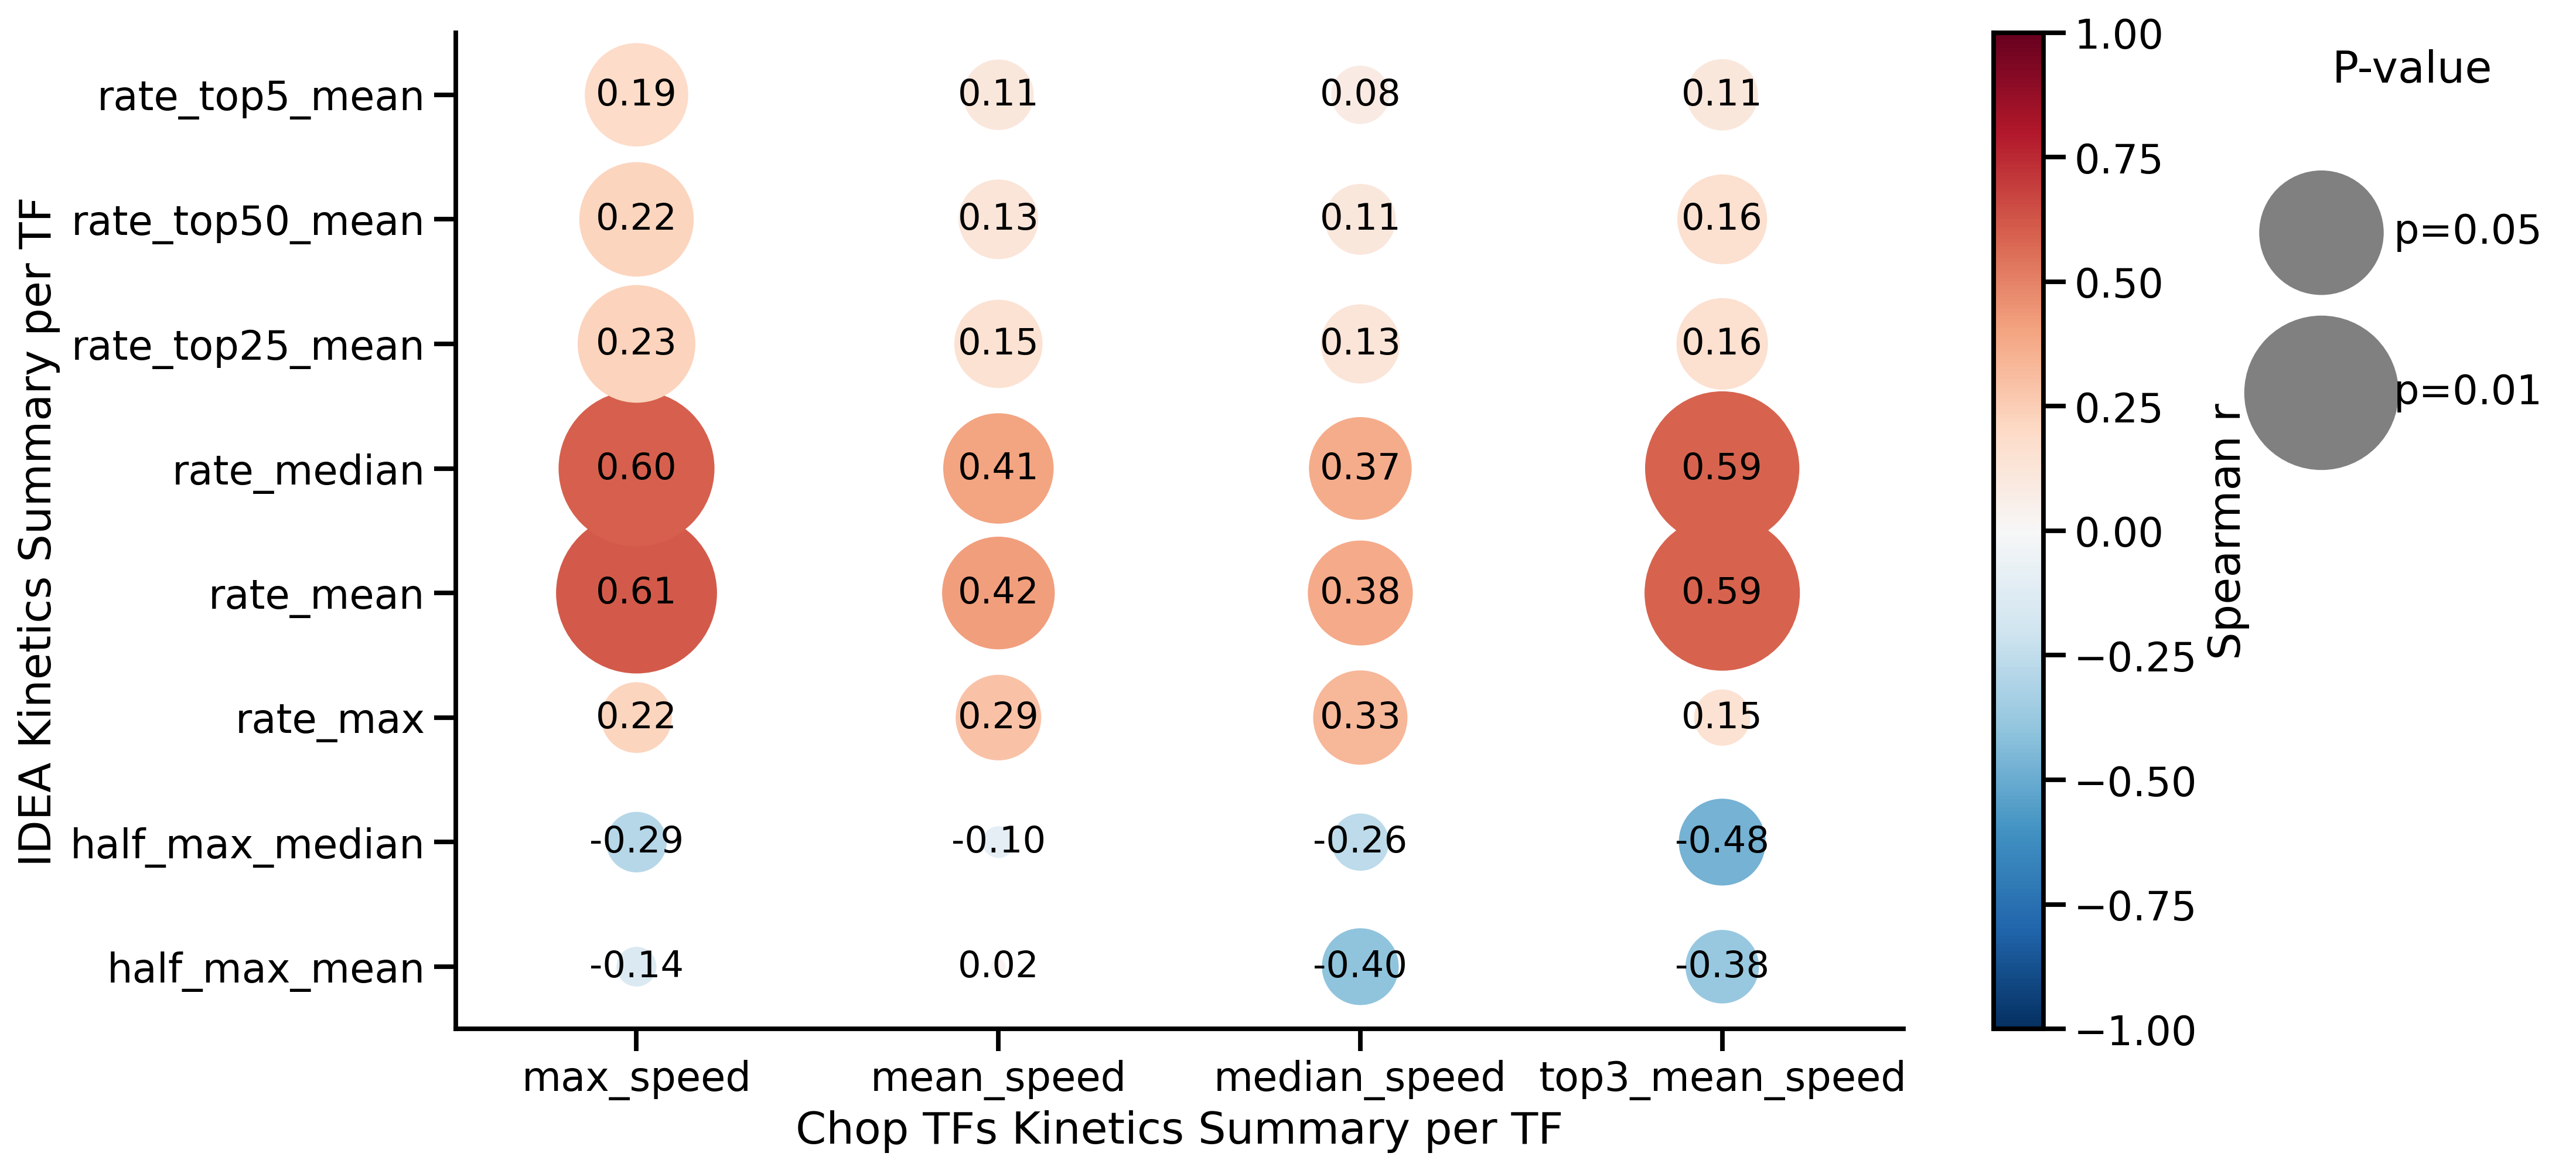

In [75]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
sns.set_context('talk')

kinetics_labels = pivot_r.index.tolist()
speed_labels    = pivot_r.columns.tolist()

xs, ys, colors, sizes, annots = [], [], [], [], []
for i, k in enumerate(kinetics_labels):
    for j, s in enumerate(speed_labels):
        r = pivot_r.loc[k, s]
        p = pivot_p.loc[k, s]
        xs.append(j)
        ys.append(i)
        colors.append(r)
        sizes.append(-np.log10(p) * 2000)
        annots.append(f'{r:.2f}')

cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-1, vmax=1)

fig, ax = plt.subplots(figsize=(15,7), dpi=300)
sc = ax.scatter(xs, ys, c=colors, s=sizes, cmap=cmap, norm=norm,
                edgecolors='none', linewidths=0.4)

for x, y, txt in zip(xs, ys, annots):
    ax.text(x, y, txt, ha='center', va='center', fontsize='small')

plt.colorbar(sc, ax=ax, label='Spearman r')

# size legend using representative p-values
for p_val, label in [(0.05, 'p=0.05'), (0.01, 'p=0.01')]:
    ax.scatter([], [], s=-np.log10(p_val) * 2000,
               color='grey', edgecolors='none', label=label)
ax.legend(title='P-value', frameon=False, loc='upper left',
          bbox_to_anchor=(1.25, 1), borderaxespad=0, labelspacing=3)

ax.set_xticks(range(len(speed_labels)))
ax.set_xticklabels(speed_labels)
ax.set_yticks(range(len(kinetics_labels)))
ax.set_yticklabels(kinetics_labels)
ax.set_xlim(-0.5, len(speed_labels) - 0.5)
ax.set_ylim(-0.5, len(kinetics_labels) - 0.5)

ax.set_xlabel("Chop TFs Kinetics Summary per TF")
ax.set_ylabel("IDEA Kinetics Summary per TF")

sns.despine()
plt.tight_layout()
plt.show()

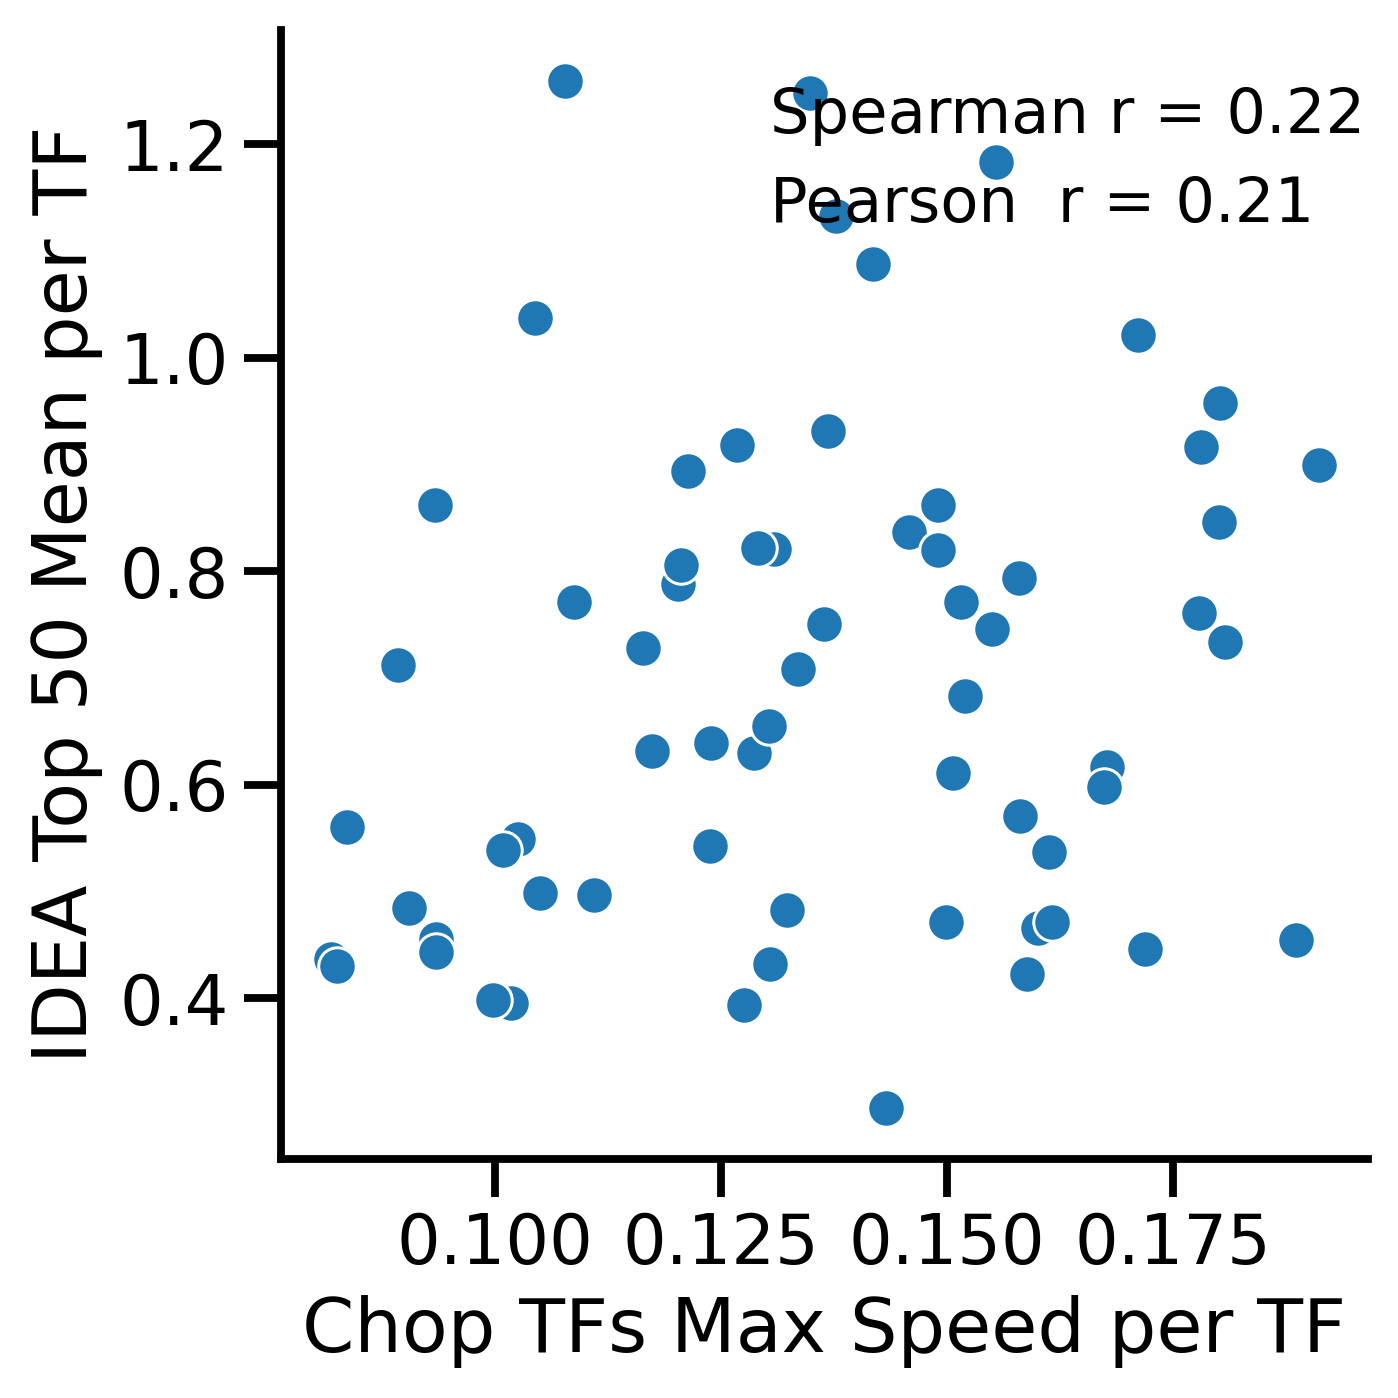

In [70]:
from scipy import stats

tmp = merged[["max_speed", "rate_top50_mean"]].dropna()
r_sp, p_sp = stats.spearmanr(tmp["max_speed"], tmp["rate_top50_mean"])
r_pe, p_pe = stats.pearsonr(tmp["max_speed"],  tmp["rate_top50_mean"])

fig, ax = plt.subplots(figsize=(5,5), dpi=300)
sns.scatterplot(data=merged, x="max_speed", y="rate_top50_mean", ax=ax)

ax.text(
    0.45, 0.95,
    f"Spearman r = {r_sp:.2f}\nPearson  r = {r_pe:.2f}",
    transform=ax.transAxes, va='top', ha='left', fontsize='small',
    linespacing=1.6,
)

ax.set_ylabel("IDEA Top 50 Mean per TF")
ax.set_xlabel("Chop TFs Max Speed per TF")
sns.despine()
plt.tight_layout()
plt.show()

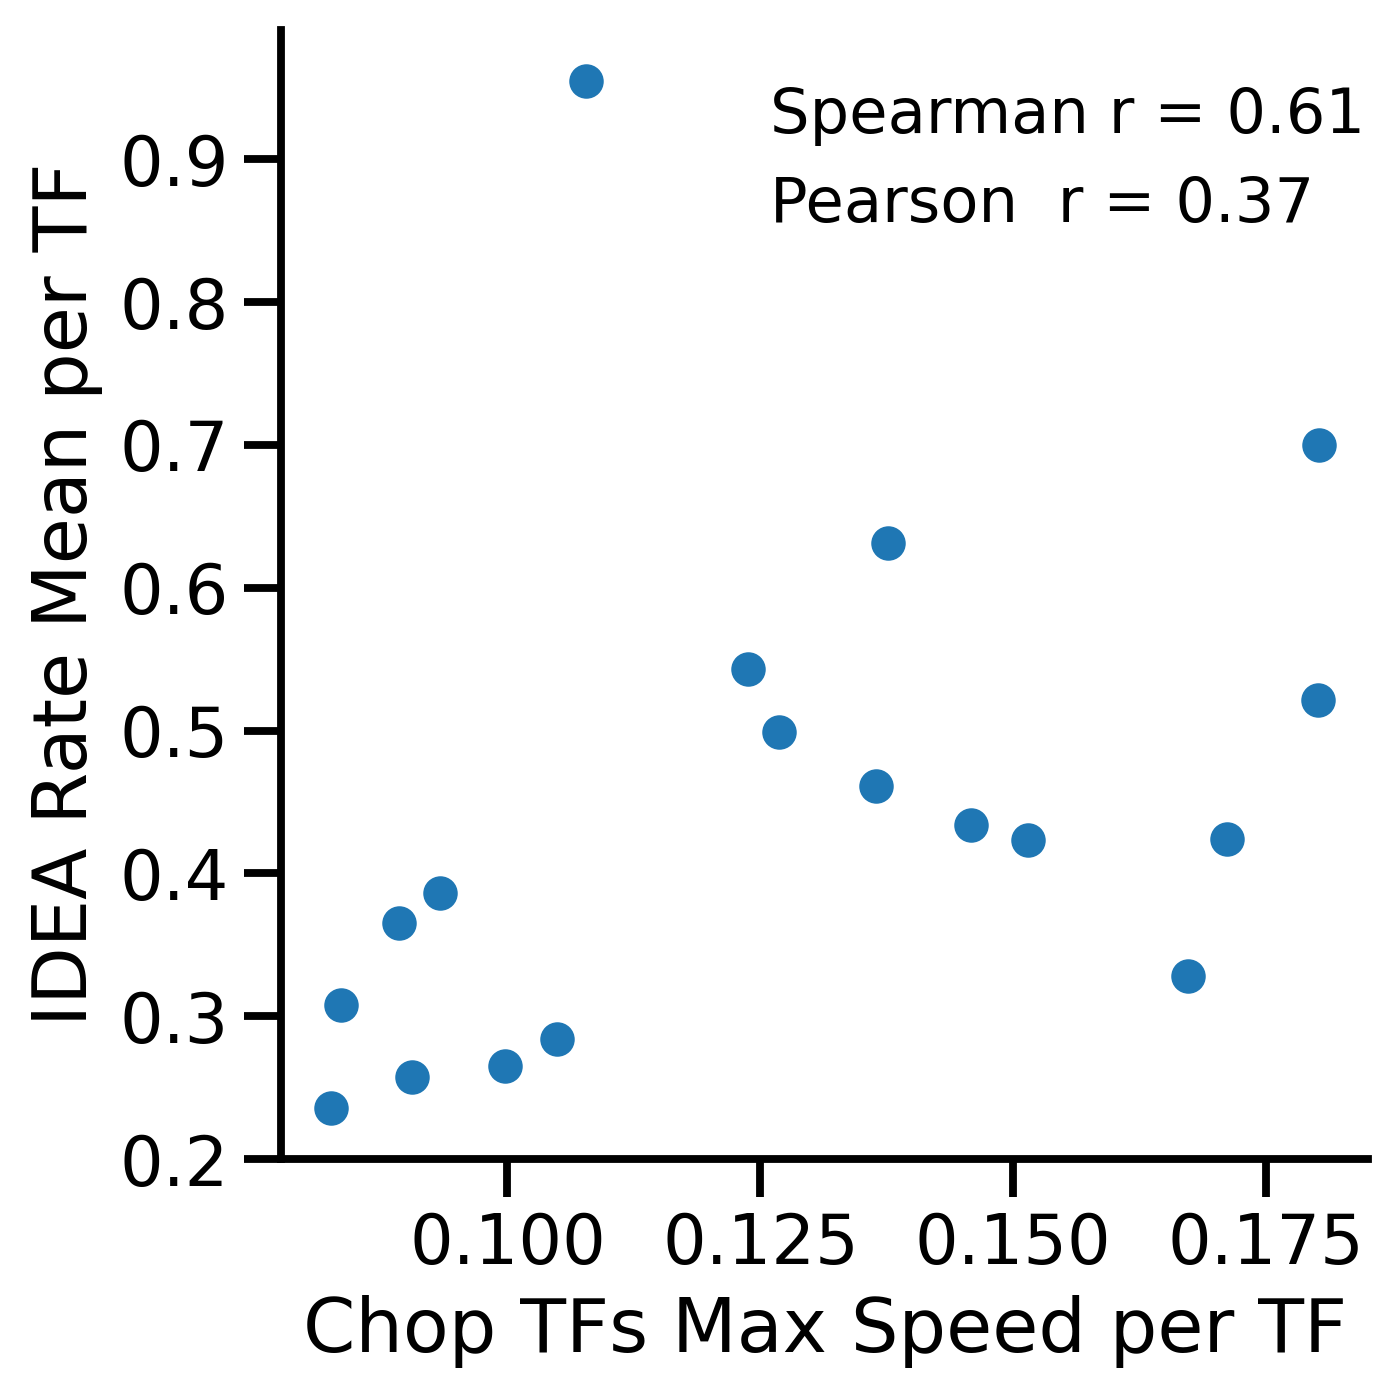

In [67]:
from scipy import stats

tmp = merged[["max_speed", "rate_mean"]].dropna()
r_sp, p_sp = stats.spearmanr(tmp["max_speed"], tmp["rate_mean"])
r_pe, p_pe = stats.pearsonr(tmp["max_speed"],  tmp["rate_mean"])

fig, ax = plt.subplots(figsize=(5,5), dpi=300)
sns.scatterplot(data=merged, x="max_speed", y="rate_mean", ax=ax)

ax.text(
    0.45, 0.95,
    f"Spearman r = {r_sp:.2f}\nPearson  r = {r_pe:.2f}",
    transform=ax.transAxes, va='top', ha='left', fontsize='small',
    linespacing=1.6,
)

ax.set_ylabel("IDEA Rate Mean per TF")
ax.set_xlabel("Chop TFs Max Speed per TF")
sns.despine()
plt.tight_layout()
plt.show()